# V-JEPA 2.1 × OLMo-Earth — Debug Notebook

**Sections:**
1. Install packages
2. Inspect TAR file (requires actual TAR files — skip if not downloaded yet)
3. Test OLMoEarthDataset data processing
4. Model smoke test — 384px random tensor forward pass (no checkpoint needed)

> Run section 4 independently to verify model architecture before data is available.

## 1. Install packages

In [1]:
!pip install rasterio webdataset einops pyyaml torch

## 2. Inspect TAR file

**Set `TAR_GLOB` to the actual path of your downloaded TAR files.**  
This cell verifies: number of channels, value range (determines `dn_scale`), and webdataset key name.

In [2]:
import sys, os
from pathlib import Path

# ── configure these paths ──────────────────────────────────────────────────
PROJECT_ROOT = Path(".").resolve()          # adjust if notebook is not in project root
TAR_GLOB     = "*.tar"
# ──────────────────────────────────────────────────────────────────────────

sys.path.insert(0, str(PROJECT_ROOT))
sys.path.insert(0, str(PROJECT_ROOT / "vjepa2"))
print(f"Project root: {PROJECT_ROOT}")

Project root: C:\My_Resources\work01\VJEPA2.1FineTune


In [3]:
import glob as _glob
tar_files = sorted(_glob.glob(TAR_GLOB))
print(f"Found {len(tar_files)} TAR file(s)")
for f in tar_files[:5]:
    size_mb = os.path.getsize(f) / 1e6
    print(f"  {Path(f).name}  {size_mb:.0f} MB")

Found 1 TAR file(s)
  0000.tar  48352 MB


In [4]:
import webdataset as wds
import numpy as np

if tar_files:
    ds = wds.WebDataset(tar_files[:1])
    sample = next(iter(ds))

    print("All keys in sample:")
    for k, v in sample.items():
        if not k.startswith("__"):
            vtype = type(v).__name__
            vlen  = len(v) if hasattr(v, "__len__") else "-"
            print(f"  key={k!r:20s}  type={vtype:10s}  len={vlen}")
    print(f"__key__: {sample.get('__key__')}")
else:
    print("No TAR files found — set TAR_GLOB above")

All keys in sample:
  key='tif'                 type=bytes       len=213744
__key__: 10_sentinel2_l2a_monthly/EPSG:32635_272_-2075_40


In [5]:
# Decode the GeoTIFF and check shape / value range
# If 'tif' key is missing, adjust TIF_KEY to the actual key printed above
TIF_KEY = "tif"

if tar_files and TIF_KEY in sample:
    import rasterio
    from rasterio.io import MemoryFile

    with MemoryFile(sample[TIF_KEY]) as mf, mf.open() as src:
        arr  = src.read().astype(np.float32)   # [C, H, W]
        meta = src.meta

    C, H, W = arr.shape
    print(f"GeoTIFF shape (C, H, W): {arr.shape}")
    print(f"dtype: {meta['dtype']}    CRS: {meta.get('crs')}")

    MISSING = -99999.0
    valid = arr[arr != MISSING]
    print(f"\nValue range (excl. MISSING): [{valid.min():.2f}, {valid.max():.2f}]")
    print(f"Missing fraction: {(arr == MISSING).mean():.3%}")

    N_MONTHS = 12
    if C % N_MONTHS == 0:
        bpt = C // N_MONTHS
        print(f"\n→ {C} channels = {N_MONTHS} months × {bpt} bands/month")
        print(f"  Set n_bands_per_timestep={bpt} in YAML")

    if valid.max() > 10.0:
        print("→ DN range detected — dn_scale=10000.0  ✓")
    elif valid.max() <= 1.01:
        print("→ Reflectance range — dn_scale=1.0")
    else:
        print(f"→ Ambiguous range ({valid.max():.1f}) — check documentation")
else:
    print(f"Key {TIF_KEY!r} not in sample — check keys printed above")

GeoTIFF shape (C, H, W): (24, 64, 64)
dtype: uint16    CRS: EPSG:32635

Value range (excl. MISSING): [1.00, 12187.00]
Missing fraction: 0.000%

→ 24 channels = 12 months × 2 bands/month
  Set n_bands_per_timestep=2 in YAML
→ DN range detected — dn_scale=10000.0  ✓


## 3. Test OLMoEarthDataset data processing

In [6]:
from data_pipeline.olmoearth_dataset import OLMoEarthDataset

if tar_files:
    ds_oe = OLMoEarthDataset(
        tar_path=TAR_GLOB,
        n_bands_per_timestep=4,   # 10_sentinel2_l2a_monthly
        tif_key=TIF_KEY,
        crop_size=256,
        dn_scale=10000.0,
    )
    print(f"Dataset initialized: {len(ds_oe.tar_files)} TAR shards")

    it = iter(ds_oe)
    sample_out = next(it)
    buffers, label, doys, clip_indices = sample_out

    print(f"buffer shape:  {buffers[0].shape}   expected [4, 12, 256, 256]")
    print(f"buffer dtype:  {buffers[0].dtype}")
    print(f"buffer range:  [{buffers[0].min():.3f}, {buffers[0].max():.3f}]  (z-scored)")
    print(f"doy tensor:    {doys}")
    print(f"clip_indices:  {clip_indices[0]}")
    assert buffers[0].shape == (4, 12, 256, 256), "SHAPE MISMATCH"
    assert doys.shape == (12,), "DOY shape wrong"
    assert isinstance(clip_indices[0], type(clip_indices[0])), "clip_indices type wrong"
    print("\n✓ Data processing OK")
else:
    print("Skip — no TAR files")

Dataset initialized: 1 TAR shards
buffer shape:  torch.Size([4, 12, 256, 256])   expected [4, 12, 256, 256]
buffer dtype:  torch.float32
buffer range:  [-2.599, 13.946]  (z-scored)
doy tensor:    tensor([ 15,  46,  74, 105, 135, 166, 196, 227, 258, 288, 319, 349],
       dtype=torch.int32)
clip_indices:  [ 0  1  2  3  4  5  6  7  8  9 10 11]

✓ Data processing OK


## 4. Model smoke test — 384px random forward pass

No checkpoint required.  
Tests full pipeline: encoder → target_encoder → predictor → JEPA loss.

In [7]:
import copy
import torch
import torch.nn as nn

import app.vjepa_2_1.models.predictor as vit_pred
import app.vjepa_2_1.models.vision_transformer as video_vit
from app.vjepa_2_1.wrappers import MultiSeqWrapper, PredictorMultiSeqWrapper
from src.masks.utils import apply_masks

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {device}")

# ── hyper-params matching OLMo-Earth fine-tune (but 384px for the smoke test) ─
IMG_SIZE   = 384   # pretrained resolution — pos_embed will be valid at this size
PATCH_SIZE = 16
IN_CHANS   = 4     # B02 B03 B04 B08 (10_sentinel2_l2a_monthly)
FRAMES     = 12    # 12 monthly composites
TUBELET    = 2
EMBED_DIM  = 1024  # ViT-L
BATCH      = 1

N_SPATIAL = (IMG_SIZE // PATCH_SIZE) ** 2          # 576
N_TEMPORAL = FRAMES // TUBELET                      # 6
N_TOKENS = N_SPATIAL * N_TEMPORAL                   # 3456
print(f"Tokens: {N_SPATIAL} spatial × {N_TEMPORAL} temporal = {N_TOKENS} total")

Device: cuda
Tokens: 576 spatial × 6 temporal = 3456 total


In [8]:
# Build encoder
encoder_backbone = video_vit.vit_large(
    img_size=IMG_SIZE,
    patch_size=PATCH_SIZE,
    num_frames=FRAMES,
    tubelet_size=TUBELET,
    in_chans=IN_CHANS,
    use_doy_encoding=True,
    use_rope=False,
    uniform_power=True,
    use_sdpa=True,
    use_activation_checkpointing=False,
    modality_embedding=False,
    has_cls_first=False,
    n_registers=0,
)

# Build predictor
predictor_backbone = vit_pred.vit_predictor(
    img_size=IMG_SIZE,
    patch_size=PATCH_SIZE,
    num_frames=FRAMES,
    tubelet_size=TUBELET,
    embed_dim=EMBED_DIM,
    predictor_embed_dim=384,
    depth=12,
    num_heads=12,
    uniform_power=True,
    use_mask_tokens=True,
    zero_init_mask_tokens=True,
    use_rope=False,
    use_sdpa=True,
    use_activation_checkpointing=False,
    n_registers=0,
    has_cls_first=False,
    modality_embedding=False,
)

encoder       = MultiSeqWrapper(encoder_backbone).to(device)
predictor     = PredictorMultiSeqWrapper(predictor_backbone).to(device)
target_encoder = copy.deepcopy(encoder)
for p in target_encoder.parameters():
    p.requires_grad = False

enc_params  = sum(p.numel() for p in encoder.parameters())
pred_params = sum(p.numel() for p in predictor.parameters())
print(f"Encoder params:   {enc_params:,}")
print(f"Predictor params: {pred_params:,}")
print("✓ Model built")

Encoder params:   307,958,784
Predictor params: 28,788,096
✓ Model built


In [9]:
# ── random inputs ─────────────────────────────────────────────────────────────
x    = torch.randn(BATCH, IN_CHANS, FRAMES, IMG_SIZE, IMG_SIZE, device=device, dtype=torch.bfloat16)
doys = torch.tensor([[15, 46, 74, 105, 135, 166, 196, 227, 258, 288, 319, 349]] * BATCH, device=device)

# Simple context/predict split: 70% context, 30% predict
n_ctx  = int(N_TOKENS * 0.70)
n_pred = N_TOKENS - n_ctx
perm   = torch.randperm(N_TOKENS, device=device)
ctx_mask  = perm[:n_ctx].unsqueeze(0).expand(BATCH, -1)   # [B, n_ctx]
pred_mask = perm[n_ctx:].unsqueeze(0).expand(BATCH, -1)   # [B, n_pred]

# masks format: list[list[Tensor]]  — outer=clips, inner=mask blocks
masks_enc  = [[ctx_mask]]
masks_pred = [[pred_mask]]

print(f"Input:       {list(x.shape)}  {x.dtype}")
print(f"DOYs:        {list(doys.shape)}")
print(f"ctx tokens:  {n_ctx}   pred tokens: {n_pred}")

Input:       [1, 4, 12, 384, 384]  torch.bfloat16
DOYs:        [1, 12]
ctx tokens:  2419   pred tokens: 1037


In [10]:
# ── forward pass ──────────────────────────────────────────────────────────────
# The predictor's predictor_embed is Linear(embed_dim * 4, pred_dim) because
# it expects hierarchical encoder features from 4 distillation layers.
# training_mode=True makes VisionTransformer.forward() return
# torch.cat(hier, dim=2) → [B, N, 4 * embed_dim = 4096] instead of [B, N, 1024].
encoder.train()
predictor.train()
target_encoder.eval()

with torch.autocast(device_type=device.type, dtype=torch.bfloat16):
    # 1. Context encoding (masked) — hierarchical output [B, n_ctx, 4*1024=4096]
    z_ctx = encoder([x], masks=masks_enc, doys=doys, training_mode=True)
    print(f"z_ctx:  {len(z_ctx)} clip(s) × {len(z_ctx[0])} block(s)  shape={z_ctx[0][0].shape}")
    # expected: [B, n_ctx, 4096]

    # 2. Target encoding (EMA, full sequence) — same hierarchical dims for loss consistency
    with torch.no_grad():
        z_tgt_full = target_encoder([x], doys=doys, training_mode=True)
        print(f"z_tgt_full: shape={z_tgt_full[0].shape}")
        # expected: [B, N_TOKENS, 4096]

        z_tgt = [
            [apply_masks(z, m) for m in mp]
            for z, mp in zip(z_tgt_full, masks_pred)
        ]
        print(f"z_tgt:  shape={z_tgt[0][0].shape}")
        # expected: [B, n_pred, 4096]

    # 3. Predictor
    z_pred, _ = predictor(z_ctx, masks_enc, masks_pred)
    print(f"z_pred: shape={z_pred[0][0].shape}")
    # expected: [B, n_pred, 4096]

    # 4. JEPA loss
    loss, n = 0.0, 0
    for zp_list, zt_list in zip(z_pred, z_tgt):
        for zp, zt in zip(zp_list, zt_list):
            loss = loss + nn.functional.smooth_l1_loss(zp, zt)
            n += 1
    loss = loss / max(n, 1)

print(f"\n✓ Forward pass complete!  loss = {loss.item():.6f}")
assert not torch.isnan(loss), "Loss is NaN — check model init"
assert not torch.isinf(loss), "Loss is Inf — check model init"

z_ctx:  1 clip(s) × 1 block(s)  shape=torch.Size([1, 2419, 4096])
z_tgt_full: shape=torch.Size([1, 3456, 4096])
z_tgt:  shape=torch.Size([1, 1037, 4096])
z_pred: shape=torch.Size([1, 1037, 4096])

✓ Forward pass complete!  loss = 0.474982


In [11]:
# ── backward pass ─────────────────────────────────────────────────────────────
loss.backward()
grad_norms = [
    p.grad.norm().item()
    for p in encoder.parameters()
    if p.grad is not None
]
print(f"Encoder grad norms: min={min(grad_norms):.4e}  max={max(grad_norms):.4e}  n={len(grad_norms)}")
assert all(not (g != g) for g in grad_norms), "NaN gradient detected"
print("✓ Backward pass complete — gradients look sane")
print("\n=== ALL SMOKE TESTS PASSED ===")

Encoder grad norms: min=1.7269e-05  max=2.4847e-02  n=299
✓ Backward pass complete — gradients look sane

=== ALL SMOKE TESTS PASSED ===


## 5. Full pipeline test with actual TAR data

Builds a 256 px / 4-ch model matching the OLMo-Earth tile size and runs one
forward + backward pass on the real buffer loaded in Section 3.

Requires Section 3 to have been run first (`sample_out` must be defined).

In [12]:
import copy
import torch
import torch.nn as nn
import app.vjepa_2_1.models.predictor as vit_pred
import app.vjepa_2_1.models.vision_transformer as video_vit
from app.vjepa_2_1.wrappers import MultiSeqWrapper, PredictorMultiSeqWrapper
from src.masks.utils import apply_masks
from data_pipeline.patch_embed_6ch import build_nch_patch_embed_from_pretrained

IMG256    = 256
IN_CHANS4 = 4
FRAMES12  = 12
TUBELET2  = 2
EMBED_L   = 1024

N_SP  = (IMG256 // 16) ** 2
N_TMP = FRAMES12 // TUBELET2
N_TOK = N_SP * N_TMP   # 1536
print(f"256px tokens: {N_SP} spatial x {N_TMP} temporal = {N_TOK} total")

# use_rope=True matches the pretrained checkpoint (no pos_embed in checkpoint).
enc_bb = video_vit.vit_large(
    img_size=IMG256, patch_size=16, num_frames=FRAMES12, tubelet_size=TUBELET2,
    in_chans=IN_CHANS4, use_doy_encoding=True, use_rope=True,
    uniform_power=True, use_sdpa=True, use_activation_checkpointing=False,
    modality_embedding=False, has_cls_first=False, n_registers=0,
)
pred_bb = vit_pred.vit_predictor(
    img_size=IMG256, patch_size=16, num_frames=FRAMES12, tubelet_size=TUBELET2,
    embed_dim=EMBED_L, predictor_embed_dim=384, depth=12, num_heads=12,
    uniform_power=True, use_mask_tokens=True, zero_init_mask_tokens=True,
    use_rope=True, use_sdpa=True, use_activation_checkpointing=False,
    n_registers=0, has_cls_first=False, modality_embedding=False,
)
enc256  = MultiSeqWrapper(enc_bb).to(device)
pred256 = PredictorMultiSeqWrapper(pred_bb).to(device)

def _strip_prefix(sd):
    if not sd: return sd
    key = next(iter(sd))
    for pfx in ("module.backbone.", "module.", "backbone."):
        if key.startswith(pfx):
            return {k[len(pfx):]: v for k, v in sd.items()}
    return sd

def _safe_load(module, state_dict):
    own = module.state_dict()
    compatible = {k: v for k, v in state_dict.items()
                  if k not in own or own[k].shape == v.shape}
    return module.load_state_dict(compatible, strict=False)

CKPT_PATH = PROJECT_ROOT / "vjepa2_1_vitl_dist_vitG_384.pt"
if CKPT_PATH.exists():
    print(f"Loading: {CKPT_PATH.name}")
    ckpt = torch.load(str(CKPT_PATH), map_location="cpu")
    enc_state = _strip_prefix(ckpt.get("encoder", ckpt))

    new_pe = build_nch_patch_embed_from_pretrained(
        pretrained_state_dict=enc_state,
        in_chans=IN_CHANS4, patch_size=16, tubelet_size=TUBELET2, embed_dim=EMBED_L,
    ).to(device)
    enc256.backbone.patch_embed = new_pe

    enc_filtered = {k: v for k, v in enc_state.items() if not k.startswith("patch_embed")}
    msg = _safe_load(enc256.backbone, enc_filtered)
    missing_imp = [k for k in msg.missing_keys
                   if not k.startswith(("doy_encoding", "patch_embed", "pos_embed"))]
    print(f"  Encoder  missing(important)={len(missing_imp)}  unexpected={len(msg.unexpected_keys)}")
    if missing_imp:
        print(f"  WARNING unexpected missing: {missing_imp[:3]}")

    if "predictor" in ckpt:
        # Checkpoint predictor was built for ViT-G distillation (different out_dim).
        # _safe_load skips shape-mismatched keys; blocks transfer, proj layers stay random.
        pred_state = _strip_prefix(ckpt["predictor"])
        msg2 = _safe_load(pred256.backbone, pred_state)
        print(f"  Predictor missing={len(msg2.missing_keys)}  unexpected={len(msg2.unexpected_keys)}")

    status = "Checkpoint loaded successfully" if not missing_imp else "WARNING: check missing keys"
    print(status)
else:
    print(f"WARNING: {CKPT_PATH.name} not found — random init")

tgt256 = copy.deepcopy(enc256)
for p in tgt256.parameters():
    p.requires_grad = False
print(f"Encoder params: {sum(p.numel() for p in enc256.parameters()):,}")
print("Model ready")


256px tokens: 256 spatial x 6 temporal = 1536 total
Loading: vjepa2_1_vitl_dist_vitG_384.pt
  patch_embed: initialized 4ch from averaged RGB weights torch.Size([1024, 3, 2, 16, 16]) → torch.Size([1024, 4, 2, 16, 16])
  Encoder  missing(important)=0  unexpected=2
  Predictor missing=6  unexpected=12
Checkpoint loaded successfully
Encoder params: 304,419,840
Model ready


In [13]:
from src.masks.multiseq_multiblock3d import MaskCollator

# ── prepare real data from Section 3 ──────────────────────────────────────
buffers_r, _, doys_r, _ = sample_out

x_r    = buffers_r[0].unsqueeze(0).to(device, dtype=torch.bfloat16)  # [1,4,12,256,256]
doys_r = doys_r.unsqueeze(0).to(device)                              # [1,12]
print(f'Real input shape: {list(x_r.shape)}  dtype={x_r.dtype}')

# ── V-JEPA block masks (matches olmoearth-256px-12f.yaml) ─────────────────
# Gen0: 8 small blocks, 15% spatial scale, full temporal → context holes
# Gen1: 2 large blocks, 70% spatial scale, full temporal → main target
cfgs_mask = [
    {
        'aspect_ratio': [0.75, 1.5], 'num_blocks': 8,
        'spatial_scale': [0.15, 0.15], 'temporal_scale': [1.0, 1.0],
        'max_temporal_keep': 1.0, 'full_complement': False, 'max_keep': None,
    },
    {
        'aspect_ratio': [0.75, 1.5], 'num_blocks': 2,
        'spatial_scale': [0.7, 0.7], 'temporal_scale': [1.0, 1.0],
        'max_temporal_keep': 1.0, 'full_complement': False, 'max_keep': None,
    },
]
collator = MaskCollator(
    cfgs_mask=cfgs_mask,
    dataset_fpcs=[12],
    crop_size=(256, 256),
    patch_size=(16, 16),
    tubelet_size=2,
)

# Generate block masks for batch_size=1
masks_enc_all, masks_pred_all = [], []
for gen in collator.mask_generators[12]:
    enc_m, pred_m = gen(batch_size=1)
    masks_enc_all.append(enc_m.to(device))
    masks_pred_all.append(pred_m.to(device))

# Format: [[gen0_mask, gen1_mask]] — outer=clips, inner=mask generators
masks_enc_r  = [masks_enc_all]
masks_pred_r = [masks_pred_all]

# Expose gen1 masks (2 large 70%-spatial blocks) for Section 6 visualization
ctx_mask_r  = masks_enc_r[0][1]   # [1, n_ctx]
pred_mask_r = masks_pred_r[0][1]  # [1, n_pred]
n_ctx_r  = ctx_mask_r.shape[1]
n_pred_r = pred_mask_r.shape[1]
print(f'Gen0 (8 small blocks)  ctx={masks_enc_all[0].shape[1]:5d}  pred={masks_pred_all[0].shape[1]}')
print(f'Gen1 (2 large blocks)  ctx={masks_enc_all[1].shape[1]:5d}  pred={masks_pred_all[1].shape[1]}')

# ── forward + backward ────────────────────────────────────────────────────────
enc256.train(); pred256.train(); tgt256.eval()

with torch.autocast(device_type=device.type, dtype=torch.bfloat16):
    # Context encoding: encoder sees patches NOT in any target block
    # training_mode=True → hierarchical output [B, n_ctx, 4*1024=4096]
    z_ctx_r = enc256([x_r], masks=masks_enc_r, doys=doys_r, training_mode=True)
    print(f'z_ctx_r shapes: {[z.shape for zl in z_ctx_r for z in zl]}')

    with torch.no_grad():
        z_tgt_full_r = tgt256([x_r], doys=doys_r, training_mode=True)
        z_tgt_r = [
            [apply_masks(z, m) for m in mp]
            for z, mp in zip(z_tgt_full_r, masks_pred_r)
        ]
        print(f'z_tgt_r shapes: {[z.shape for zl in z_tgt_r for z in zl]}')

    z_pred_r, _ = pred256(z_ctx_r, masks_enc_r, masks_pred_r)
    print(f'z_pred_r shapes: {[z.shape for zl in z_pred_r for z in zl]}')

    loss_r, n = 0.0, 0
    for zp_list, zt_list in zip(z_pred_r, z_tgt_r):
        for zp, zt in zip(zp_list, zt_list):
            loss_r = loss_r + nn.functional.smooth_l1_loss(zp, zt)
            n += 1
    loss_r = loss_r / max(n, 1)

loss_r.backward()
grad_norms_r = [p.grad.norm().item() for p in enc256.parameters() if p.grad is not None]
print(f'Grad norms (encoder): min={min(grad_norms_r):.3e}  max={max(grad_norms_r):.3e}')

print(f'\n✓ Real-data forward+backward complete!  loss = {loss_r.item():.6f}')
assert not torch.isnan(loss_r), 'Loss is NaN'
assert not torch.isinf(loss_r), 'Loss is Inf'
print('\n=== ALL TESTS PASSED ===')

Real input shape: [1, 4, 12, 256, 256]  dtype=torch.bfloat16
Gen0 (8 small blocks)  ctx=  486  pred=1050
Gen1 (2 large blocks)  ctx=  456  pred=1080
z_ctx_r shapes: [torch.Size([1, 486, 4096]), torch.Size([1, 456, 4096])]
z_tgt_r shapes: [torch.Size([1, 1050, 4096]), torch.Size([1, 1080, 4096])]
z_pred_r shapes: [torch.Size([1, 1050, 4096]), torch.Size([1, 1080, 4096])]
Grad norms (encoder): min=1.101e-04  max=9.147e-02

✓ Real-data forward+backward complete!  loss = 0.292515

=== ALL TESTS PASSED ===


## 6. Visualizations — mask overlay & patch embeddings

**Cell A**: 12 monthly RGB frames with V-JEPA block mask overlay (gray = Gen1 target blocks: 2 large 70%-spatial rectangles spanning all frames).

**Cell B**: Encoder patch embeddings (last layer) projected to PCA(3) as RGB — same style as V-JEPA 2.1 paper Figure 3.

Requires Sections 3 and 5 to have been run first.

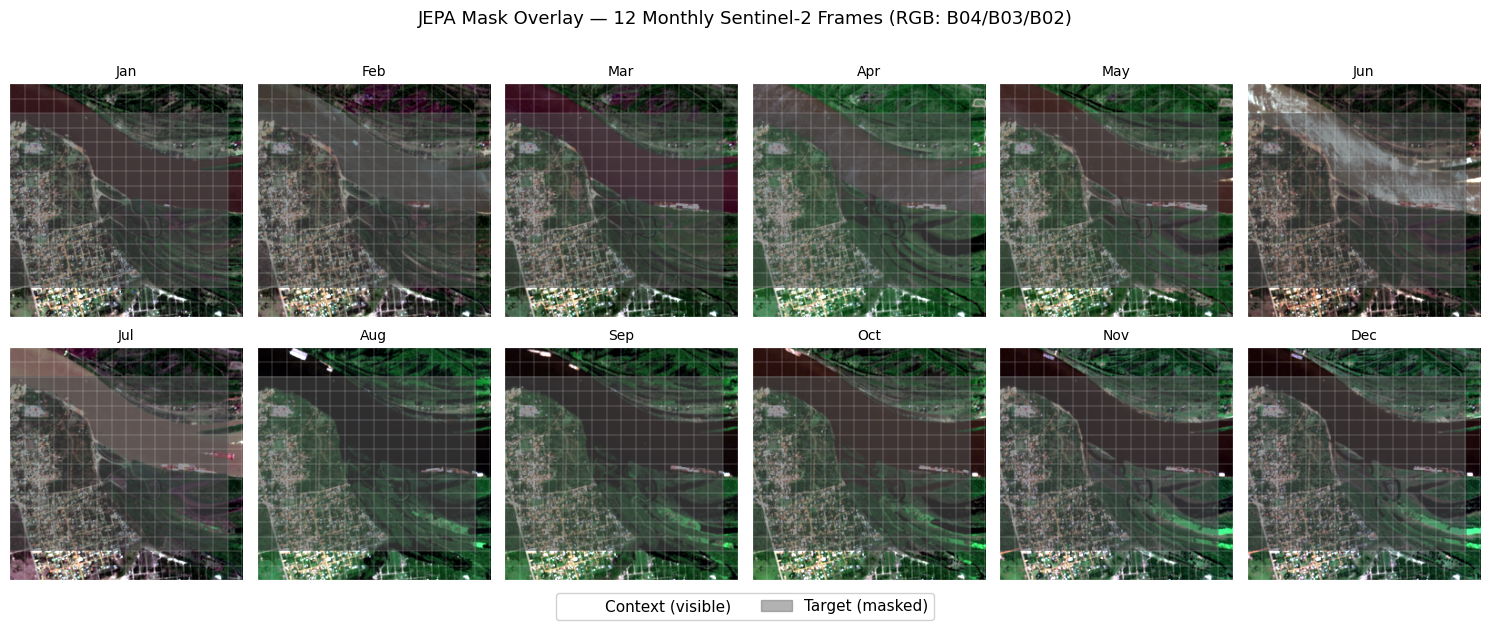

Context patches: 456  Target patches: 1080  Total: 1536


In [17]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np

# ── Un-zscore B02/B03/B04 back to reflectance for RGB display ────────────
MEAN4 = np.array([0.0850, 0.0950, 0.1001, 0.2841])
STD4  = np.array([0.0574, 0.0521, 0.0660, 0.1076])
buf = buffers_r[0].float().numpy()   # [4, 12, 256, 256]

rgb_12 = np.zeros((12, 256, 256, 3), dtype=np.float32)
for t in range(12):
    for ci, bi in enumerate([2, 1, 0]):   # B04->R  B03->G  B02->B
        ch = buf[bi, t] * STD4[bi] + MEAN4[bi]
        lo, hi = np.percentile(ch, 2), np.percentile(ch, 98)
        rgb_12[t, :, :, ci] = np.clip((ch - lo) / (hi - lo + 1e-8), 0, 1)

# ── token→patch-grid mapping ──────────────────────────────────────────────
H_PAT = W_PAT = 256 // 16   # 16 patch columns/rows
T_PAT = 12 // 2              # 6 tubelet steps

def tok_to_thw(idx):
    t  = idx // (H_PAT * W_PAT)
    hw = idx % (H_PAT * W_PAT)
    return t, hw // W_PAT, hw % W_PAT

pred_set   = set(pred_mask_r[0].cpu().numpy().tolist())
pred_patch = np.zeros((T_PAT, H_PAT, W_PAT), dtype=bool)
for tok_idx in pred_set:
    t, h, w = tok_to_thw(int(tok_idx))
    pred_patch[t, h, w] = True

# ── 2×6 subplot grid ─────────────────────────────────────────────────────
MONTH_LABELS = ['Jan','Feb','Mar','Apr','May','Jun',
                 'Jul','Aug','Sep','Oct','Nov','Dec']

fig, axes = plt.subplots(2, 6, figsize=(15, 6))
for month_t in range(12):
    row, col = month_t // 6, month_t % 6
    ax = axes[row, col]
    img = rgb_12[month_t].copy()
    tubelet_t = month_t // 2
    overlay = np.zeros((256, 256, 4), dtype=np.float32)
    for ph in range(H_PAT):
        for pw in range(W_PAT):
            if pred_patch[tubelet_t, ph, pw]:
                overlay[ph*16:(ph+1)*16, pw*16:(pw+1)*16] = [0.3, 0.3, 0.3, 0.6]
    ax.imshow(img)
    ax.imshow(overlay)
    for gi in range(0, 257, 16):
        ax.axhline(gi - 0.5, color='white', lw=0.3, alpha=0.5)
        ax.axvline(gi - 0.5, color='white', lw=0.3, alpha=0.5)
    ax.set_title(MONTH_LABELS[month_t], fontsize=10)
    ax.axis('off')

ctx_patch = mpatches.Patch(color='none', label='Context (visible)')
msk_patch = mpatches.Patch(color='gray', alpha=0.6, label='Target (masked)')
fig.legend(handles=[ctx_patch, msk_patch], loc='lower center', ncol=2,
           fontsize=11, framealpha=0.9, bbox_to_anchor=(0.5, -0.02))
fig.suptitle('JEPA Mask Overlay — 12 Monthly Sentinel-2 Frames (RGB: B04/B03/B02)',
             fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

n_pred = len(pred_set)
n_ctx  = N_TOK - n_pred
print('Context patches:', n_ctx, ' Target patches:', n_pred, ' Total:', N_TOK)

Embedding shape: (1536, 1024)
PCA variance explained: PC1=12.3%  PC2=8.6%  PC3=5.8%


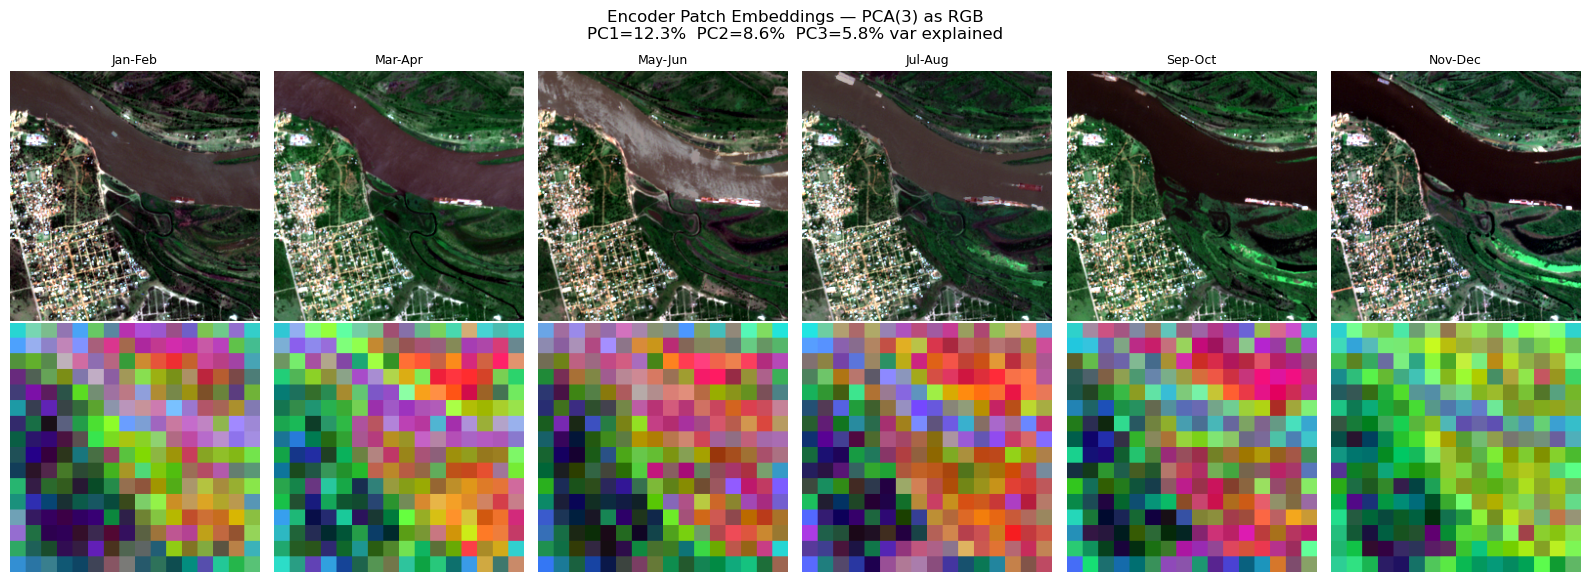

In [18]:
# ── full-sequence encoder embeddings (no mask, last-layer only) ─────────
enc256.eval()
with torch.no_grad():
    with torch.autocast(device_type=device.type, dtype=torch.bfloat16):
        z_full = enc256([x_r], doys=doys_r, training_mode=False)[0]
        # shape: [1, N_TOK, 4*1024=4096] — use only first 1024 dims for PCA
z_np = z_full[0, :, :1024].float().cpu().numpy()
        # training_mode=False → [1, N_TOK, embed_dim=1024]

# z_np = z_full[0].float().cpu().numpy()   # [1536, 1024]
print('Embedding shape:', z_np.shape)

# ── PCA(3) with NumPy (no sklearn) ───────────────────────────────────────
z_c = z_np - z_np.mean(axis=0)
cov = z_c.T @ z_c / (z_np.shape[0] - 1)   # [1024, 1024]
eigvals, eigvecs = np.linalg.eigh(cov)      # ascending order
top3   = eigvecs[:, -3:][:, ::-1]           # [1024, 3]  descending var
pca3   = z_c @ top3                         # [1536, 3]

pca_rgb = np.zeros_like(pca3)
for i in range(3):
    lo  = np.percentile(pca3[:, i], 1)
    hi  = np.percentile(pca3[:, i], 99)
    pca_rgb[:, i] = np.clip((pca3[:, i] - lo) / (hi - lo + 1e-8), 0, 1)

pca_img = pca_rgb.reshape(T_PAT, H_PAT, W_PAT, 3)   # [6, 16, 16, 3]

var_exp = eigvals[-3:] / eigvals.sum()
pc1_pct = float(var_exp[2]) * 100
pc2_pct = float(var_exp[1]) * 100
pc3_pct = float(var_exp[0]) * 100
print('PCA variance explained: PC1={:.1f}%  PC2={:.1f}%  PC3={:.1f}%'.format(
    pc1_pct, pc2_pct, pc3_pct))

# ── 2-row layout: RGB input (top)  +  PCA embedding (bottom) ─────────────
TUBELET_LABELS = ['Jan-Feb','Mar-Apr','May-Jun',
                   'Jul-Aug','Sep-Oct','Nov-Dec']

fig, axes = plt.subplots(2, 6, figsize=(16, 6))
for ti in range(T_PAT):
    m1, m2 = ti * 2, ti * 2 + 1
    avg_rgb = (rgb_12[m1] + rgb_12[m2]) / 2.0
    axes[0, ti].imshow(avg_rgb)
    axes[0, ti].set_title(TUBELET_LABELS[ti], fontsize=9)
    axes[0, ti].axis('off')

    pca_up = np.repeat(np.repeat(pca_img[ti], 16, axis=0), 16, axis=1)
    axes[1, ti].imshow(pca_up)
    axes[1, ti].axis('off')

axes[0, 0].set_ylabel('Input (RGB)', fontsize=10)
axes[1, 0].set_ylabel('Embedding PCA', fontsize=10)

title = ('Encoder Patch Embeddings — PCA(3) as RGB\n'
         'PC1={:.1f}%  PC2={:.1f}%  PC3={:.1f}% var explained').format(
    pc1_pct, pc2_pct, pc3_pct)
fig.suptitle(title, fontsize=12)
plt.tight_layout()
plt.show()